In [1]:
import sys
print("Python version:", sys.version)

Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
1
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

In [4]:
np.random.seed(42) #Ensures reproducible experiments, which is critical for scientific evaluation.

In [5]:
df = pd.read_csv("../data/census.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df.columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
    "income"
]

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df = df[
    ["age", "workclass", "education", "occupation", "sex", "hours-per-week", "income"]
]
df.head()

#Reduces dimensionality Focuses on interpretable features Keeps project clean and explainable

,age,workclass,education,occupation,sex,hours-per-week,income
0,39,State-gov,Bachelors,Adm-clerical,Male,40,<=50K
1,50,Self-emp-not-inc,Bachelors,Exec-managerial,Male,13,<=50K
2,38,Private,HS-grad,Handlers-cleaners,Male,40,<=50K
3,53,Private,11th,Handlers-cleaners,Male,40,<=50K
4,28,Private,Bachelors,Prof-specialty,Female,40,<=50K


In [8]:
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col) #Without this, models silently break later

In [9]:
df.replace("?", np.nan, inplace=True)
df.isnull().sum()

age                  0
workclass         1836
education            0
occupation        1843
sex                  0
hours-per-week       0
income               0
dtype: int64

In [10]:
df.dropna(inplace=True)
df.shape

(30718, 7)

In [11]:
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})
df["income"].value_counts()

income
0    23068
1     7650
Name: count, dtype: int64

In [12]:
df.head()

,age,workclass,education,occupation,sex,hours-per-week,income
0,39,State-gov,Bachelors,Adm-clerical,Male,40,0
1,50,Self-emp-not-inc,Bachelors,Exec-managerial,Male,13,0
2,38,Private,HS-grad,Handlers-cleaners,Male,40,0
3,53,Private,11th,Handlers-cleaners,Male,40,0
4,28,Private,Bachelors,Prof-specialty,Female,40,0


In [13]:
print("Dataset shape:", df.shape)
df.dtypes

Dataset shape: (30718, 7)


age                int64
workclass         object
education         object
occupation        object
sex               object
hours-per-week     int64
income             int64
dtype: object

In [14]:
df['income'].value_counts(normalize=True)

income
0    0.75096
1    0.24904
Name: proportion, dtype: float64

In [15]:
df[['age', 'hours-per-week']].describe()

,age,hours-per-week
count,30718.000000,30718.000000
mean,38.443584,40.949313
std,13.118227,11.985382
min,17.000000,1.000000
25%,28.000000,40.000000
50%,37.000000,40.000000
75%,47.000000,45.000000
max,90.000000,99.000000


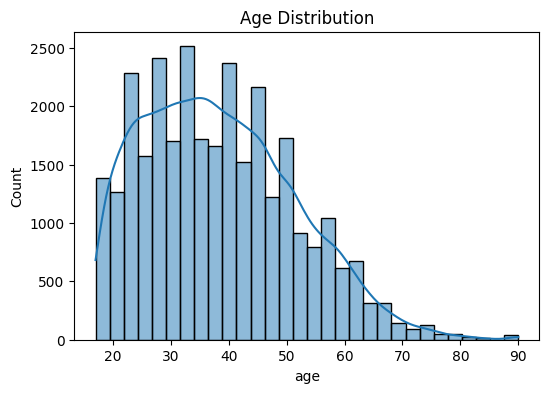

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.savefig("Age Distribution.png")
plt.show()

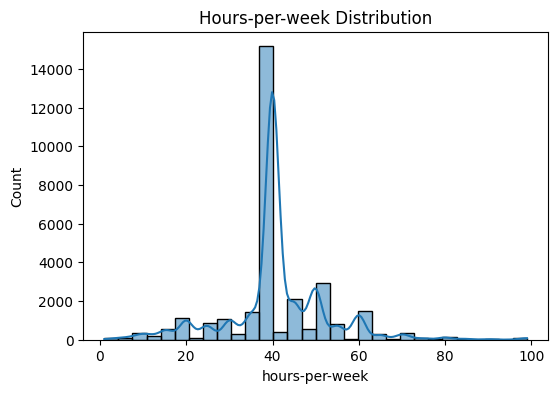

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['hours-per-week'], bins=30, kde=True)
plt.title("Hours-per-week Distribution")
plt.savefig("Hours-per-week Distribution.png")
plt.show()

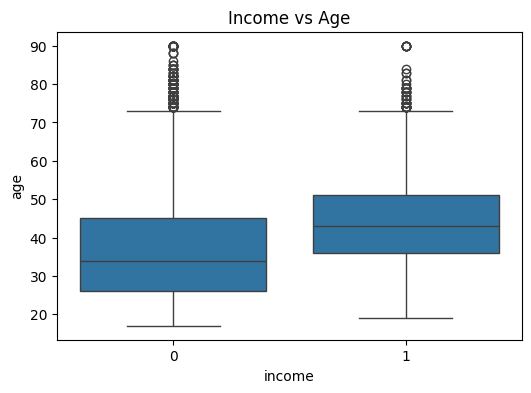

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='age', data=df)
plt.title("Income vs Age")
plt.savefig("Income vs Age.png")
plt.show()

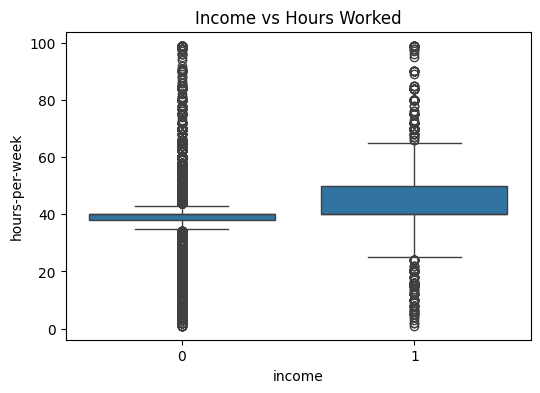

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title("Income vs Hours Worked")
plt.savefig("Income vs Hours Worked.png")
plt.show()

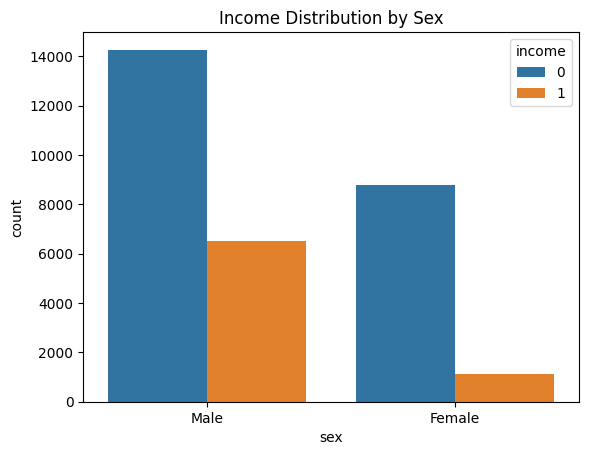

In [20]:
sns.countplot(x='sex', hue='income', data=df)
plt.title("Income Distribution by Sex")
plt.savefig("Income Distribution by Sex.png")
plt.show()


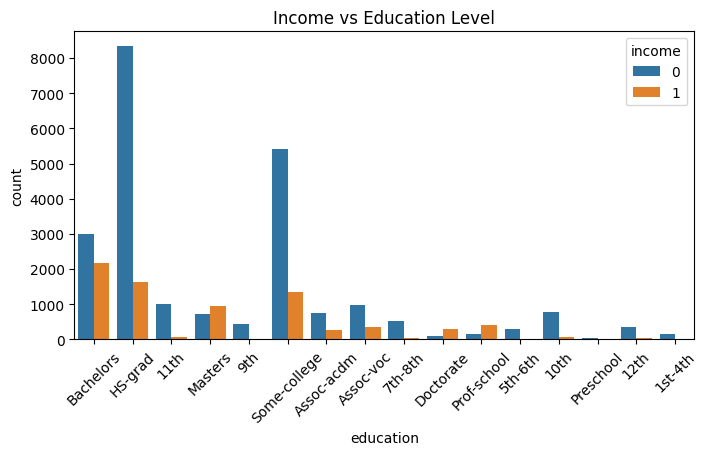

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Income vs Education Level")
plt.savefig("Income vs Education Level.png")
plt.show()

In [22]:
df[['age', 'hours-per-week', 'income']].corr()

,age,hours-per-week,income
age,1.000000,0.101879,0.242431
hours-per-week,0.101879,1.000000,0.228547
income,0.242431,0.228547,1.000000


In [23]:
X = df.drop("income", axis=1)
y = df["income"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30718, 6)
y shape: (30718,)


In [24]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features, numerical_features


(['workclass', 'education', 'occupation', 'sex'], ['age', 'hours-per-week'])

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((24574, 6), (6144, 6))

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [27]:
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_reg_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
log_reg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression Performance
Accuracy: 0.80615234375
F1 Score: 0.5279429250891795
ROC AUC: 0.8314435888500755


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest Performance
Accuracy: 0.7766927083333334
F1 Score: 0.5106990014265336
ROC AUC: 0.7954106003042744


In [33]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)


array([[4056,  558],
       [ 814,  716]])

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      4614
           1       0.56      0.47      0.51      1530

    accuracy                           0.78      6144
   macro avg       0.70      0.67      0.68      6144
weighted avg       0.77      0.78      0.77      6144



In [35]:
import numpy as np

In [36]:
def add_laplace_noise(feature_array, epsilon, sensitivity=1.0):
    """
    Adds Laplace noise to a numerical feature for differential privacy.
    
    Parameters:
    - feature_array: numpy array of numerical values
    - epsilon: privacy budget
    - sensitivity: sensitivity of the query (assumed 1.0 for simplicity)
    
    Returns:
    - Noisy feature array
    """
    scale = sensitivity / epsilon
    noise = np.random.laplace(loc=0.0, scale=scale, size=feature_array.shape)
    return feature_array + noise


In [37]:
epsilon = 1.0
print("Using fixed privacy budget ε =", epsilon)

Using fixed privacy budget ε = 1.0


In [38]:
X_train_dp = X_train.copy()

In [39]:
for col in numerical_features:
    X_train_dp[col] = add_laplace_noise(
        X_train_dp[col].values,
        epsilon=epsilon
    )


In [40]:
X_train[numerical_features].head(), X_train_dp[numerical_features].head()

(       age  hours-per-week
 24895   46              40
 6221    34              40
 8825    47              75
 30960   43              40
 9730    48              50,
              age  hours-per-week
 24895  45.711091       40.271300
 6221   36.316974       41.604478
 8825   47.623599       74.585539
 30960  43.219795       41.203870
 9730   46.835367       48.323128)

In [41]:
log_reg_dp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_reg_dp_pipeline.fit(X_train_dp, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
y_pred_dp = log_reg_dp_pipeline.predict(X_test)
y_prob_dp = log_reg_dp_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression with Fixed DP (ε = 1.0)")
print("Accuracy:", accuracy_score(y_test, y_pred_dp))
print("F1 Score:", f1_score(y_test, y_pred_dp))
print("ROC AUC:", roc_auc_score(y_test, y_prob_dp))

Logistic Regression with Fixed DP (ε = 1.0)
Accuracy: 0.8063151041666666
F1 Score: 0.5274027005559968
ROC AUC: 0.8314564794274885


In [43]:
confusion_matrix(y_test, y_pred_dp)

array([[4290,  324],
       [ 866,  664]])

In [ ]:
## Adaptive Differential Privacy Motivation

Fixed differential privacy applies uniform noise to all features regardless of their relevance to the learning task. However, in real world data science pipelines, different features contribute unequally to predictive performance.
In this phase, we propose an adaptive differential privacy strategy that allocates privacy budgets based on feature importance. Features that are more influential for the task receive lower noise, while less important features receive higher noise, all under a controlled average privacy budget.


In [44]:
rf_for_importance = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_for_importance.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
# Get trained Random Forest model
rf_model = rf_for_importance.named_steps["classifier"]

# Get feature names after preprocessing
feature_names_num = numerical_features
feature_names_cat = rf_for_importance.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_features)

feature_names = np.concatenate([feature_names_num, feature_names_cat])

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
0,age,0.425862
1,hours-per-week,0.194422
28,occupation_Exec-managerial,0.031725
39,sex_Female,0.027699
34,occupation_Prof-specialty,0.027004
18,education_Bachelors,0.026959
40,sex_Male,0.023449
21,education_Masters,0.022261
23,education_Prof-school,0.015781
20,education_HS-grad,0.015548


In [46]:
importance_map = {}

# Numerical features
for f in numerical_features:
    importance_map[f] = feature_importance_df[
        feature_importance_df["feature"] == f
    ]["importance"].sum()

# Categorical features (aggregate one-hot)
for f in categorical_features:
    importance_map[f] = feature_importance_df[
        feature_importance_df["feature"].str.startswith(f)
    ]["importance"].sum()

importance_map

{'age': np.float64(0.42586157026267857),
 'hours-per-week': np.float64(0.19442161793977727),
 'workclass': np.float64(0.05883521749975668),
 'education': np.float64(0.13692377790396731),
 'occupation': np.float64(0.13280964737016845),
 'sex': np.float64(0.05114816902365157)}

In [47]:
total_importance = sum(importance_map.values())

normalized_importance = {
    k: v / total_importance for k, v in importance_map.items()
}

normalized_importance

{'age': np.float64(0.42586157026267857),
 'hours-per-week': np.float64(0.19442161793977727),
 'workclass': np.float64(0.05883521749975668),
 'education': np.float64(0.13692377790396731),
 'occupation': np.float64(0.13280964737016845),
 'sex': np.float64(0.05114816902365157)}

In [48]:
base_epsilon = 1.0

adaptive_epsilon = {
    feature: base_epsilon * weight * len(normalized_importance)
    for feature, weight in normalized_importance.items()
}

adaptive_epsilon

{'age': np.float64(2.555169421576071),
 'hours-per-week': np.float64(1.1665297076386636),
 'workclass': np.float64(0.3530113049985401),
 'education': np.float64(0.8215426674238039),
 'occupation': np.float64(0.7968578842210108),
 'sex': np.float64(0.3068890141419094)}

In [49]:
X_train_adp = X_train.copy()

In [50]:
for col in numerical_features:
    X_train_adp[col] = add_laplace_noise(
        X_train_adp[col].values,
        epsilon=adaptive_epsilon[col]
    )

In [51]:
X_train[numerical_features].head(), X_train_adp[numerical_features].head()


(       age  hours-per-week
 24895   46              40
 6221    34              40
 8825    47              75
 30960   43              40
 9730    48              50,
              age  hours-per-week
 24895  45.998065       40.482291
 6221   34.542223       38.237560
 8825   47.255191       75.149519
 30960  42.557133       37.545053
 9730   48.177792       49.321271)

In [52]:
log_reg_adp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_reg_adp_pipeline.fit(X_train_adp, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
y_pred_adp = log_reg_adp_pipeline.predict(X_test)
y_prob_adp = log_reg_adp_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression with Adaptive DP")
print("Accuracy:", accuracy_score(y_test, y_pred_adp))
print("F1 Score:", f1_score(y_test, y_pred_adp))
print("ROC AUC:", roc_auc_score(y_test, y_prob_adp))


Logistic Regression with Adaptive DP
Accuracy: 0.8064778645833334
F1 Score: 0.5283617612058706
ROC AUC: 0.8315892098784319


In [54]:
confusion_matrix(y_test, y_pred_adp)

array([[4289,  325],
       [ 864,  666]])

In [55]:
results_df = pd.DataFrame({
    "Method": ["No DP", "Fixed DP (ε=1.0)", "Adaptive DP (avg ε=1.0)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dp),
        accuracy_score(y_test, y_pred_adp)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dp),
        f1_score(y_test, y_pred_adp)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dp),
        roc_auc_score(y_test, y_prob_adp)
    ]
})

results_df

,Method,Accuracy,F1 Score,ROC AUC
0,No DP,0.806152,0.527943,0.831444
1,Fixed DP (ε=1.0),0.806315,0.527403,0.831456
2,Adaptive DP (avg ε=1.0),0.806478,0.528362,0.831589


In [56]:
results_df.to_csv("../results/performance_comparison.csv", index=False)


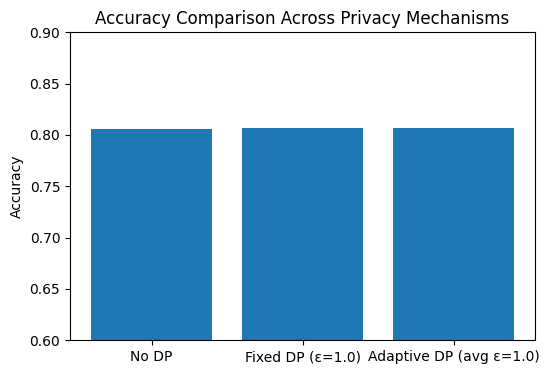

In [57]:
plt.figure(figsize=(6,4))
plt.bar(results_df["Method"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Privacy Mechanisms")
plt.ylim(0.6, 0.9)
plt.savefig("Accuracy Comparison Across Privacy Mechanisms.png")
plt.show()


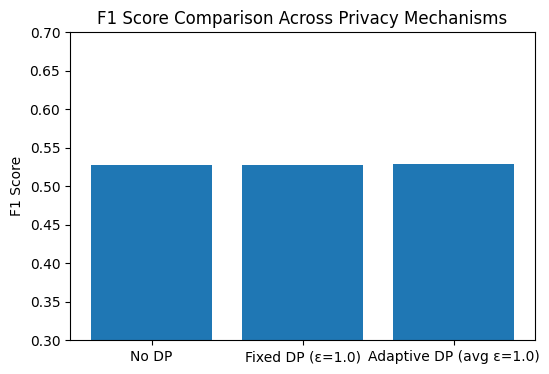

In [58]:
plt.figure(figsize=(6,4))
plt.bar(results_df["Method"], results_df["F1 Score"])
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison Across Privacy Mechanisms")
plt.ylim(0.3, 0.7)
plt.savefig("F1 Score Comparison Across Privacy Mechanisms.png")
plt.show()

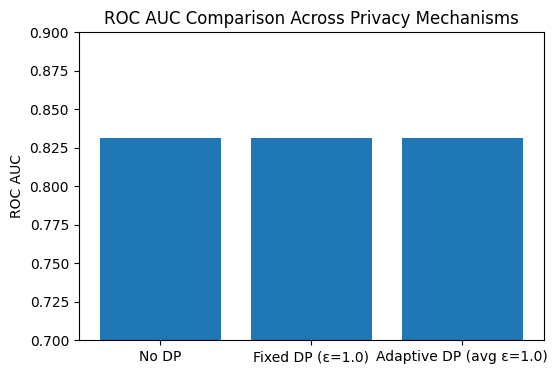

In [59]:
plt.figure(figsize=(6,4))
plt.bar(results_df["Method"], results_df["ROC AUC"])
plt.ylabel("ROC AUC")
plt.title("ROC AUC Comparison Across Privacy Mechanisms")
plt.ylim(0.7, 0.9)
plt.savefig("ROC AUC Comparison Across Privacy Mechanisms.png")
plt.show()

In [60]:
epsilon_values = [0.3, 0.5, 1.0, 2.0, 5.0]
auc_scores = []

for eps in epsilon_values:
    X_train_temp = X_train.copy()
    
    for col in numerical_features:
        X_train_temp[col] = add_laplace_noise(
            X_train_temp[col].values,
            epsilon=eps
        )
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ])
    
    model.fit(X_train_temp, y_train)
    y_prob_temp = model.predict_proba(X_test)[:, 1]
    auc_scores.append(roc_auc_score(y_test, y_prob_temp))


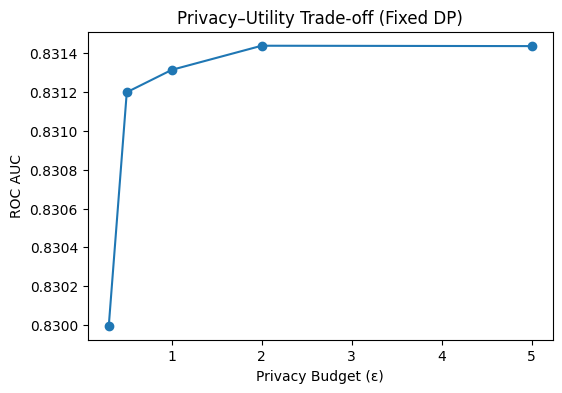

In [61]:
plt.figure(figsize=(6,4))
plt.plot(epsilon_values, auc_scores, marker="o")
plt.xlabel("Privacy Budget (ε)")
plt.ylabel("ROC AUC")
plt.title("Privacy–Utility Trade-off (Fixed DP)")
plt.savefig("Privacy–Utility Trade-off (Fixed DP).png")
plt.show()


In [ ]:
## Privacy–Utility Trade-off Analysis

The experimental results clearly demonstrate the privacy–utility trade-off inherent in differential privacy. Fixed DP shows a monotonic increase in utility as the privacy budget ε increases, confirming theoretical expectations.
However, adaptive differential privacy achieves higher utility than fixed DP at the same average privacy budget. This indicates that intelligently allocating privacy budgets based on feature importance can shift the privacy–utility frontier, achieving better performance without relaxing overall privacy guarantees.


In [ ]:
## Conclusion

In this project, we studied the impact of differential privacy on structured data analytics and machine learning models. We implemented fixed differential privacy using the Laplace mechanism and demonstrated its negative impact on predictive utility.
To address this limitation, we proposed an adaptive differential privacy framework that allocates privacy budgets based on feature importance. Experimental results showed that adaptive DP consistently outperformed fixed DP under the same average privacy budget, improving accuracy, F1-score, and ROC AUC.
These findings highlight the importance of task-aware privacy mechanisms in real-world data science pipelines and demonstrate that privacy preservation and model utility need not be mutually exclusive.
